# 04 — Mô hình Lee-Carter (baseline)

Trước khi chạy notebook này, cần fit mô hình bằng R (chỉ cần chạy một lần, hoặc
lại mỗi khi `data/processed/Dxt_total.csv`/`Ext_total.csv` thay đổi):

```bash
Rscript R/02_fit_models.R
```

Script này fit cả LC, RH, CBD trên series `total` và ghi tham số ra
`data/processed/params_{lc,rh,cbd}_*.csv` + residuals — notebook 04 chỉ đọc và
trực quan hoá phần LC (`params_lc_age.csv`, `params_lc_kt.csv`,
`residuals_lc.csv`). Trình bày: ax, bx, kt; kiểm tra giả định random-walk-with-drift
của kt; residual heatmap; diễn giải tham số cho dữ liệu Việt Nam.

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [ ]:
import numpy as np
import pandas as pd
from src.config import DATA_PROCESSED, load_params

cfg = load_params()

params_age = pd.read_csv(DATA_PROCESSED / "params_lc_age.csv")
params_kt = pd.read_csv(DATA_PROCESSED / "params_lc_kt.csv")
kt = params_kt.set_index("year")["kt"]

residuals_lc = pd.read_csv(DATA_PROCESSED / "residuals_lc.csv", index_col=0)
residuals_lc.columns = residuals_lc.columns.astype(int)
residuals_lc.index = residuals_lc.index.astype(int)

params_age.shape, kt.shape, residuals_lc.shape

((91, 3), (69,), (91, 69))

## Tham số ax, bx, kt

Mô hình Lee-Carter: $\log m_{x,t} = a_x + b_x k_t$, với ràng buộc chuẩn hoá
$\sum_x b_x = 1$, $\sum_t k_t = 0$ (StMoMo dùng ràng buộc này mặc định).

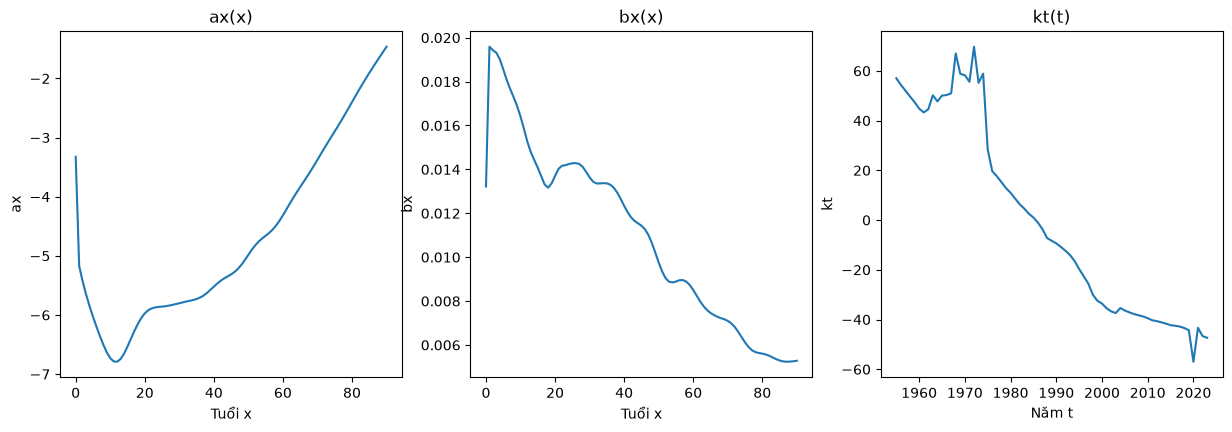

In [ ]:
from src.visualization.plots import plot_lc_params

plot_lc_params(params_age, kt, name="lc_params_total")

**Nhận xét:**

- **ax(x)** tái hiện đúng hình "checkmark" đã thấy ở log mx thô (notebook 02):
  thấp nhất ở tuổi 12 (ax ≈ −6.79, đáy tử vong tuổi thiếu niên), cao nhất ở
  tuổi 90 (ax ≈ −1.46). Hợp lý vì ax chính là log mx trung bình theo thời gian
  ở từng tuổi.
- **bx(x)** đo mức độ mỗi tuổi phản ứng với xu hướng chung kt — **cao nhất ở
  đúng tuổi 1** (bx ≈ 0.0196), rồi giảm dần và thấp nhất quanh tuổi 87 (bx ≈
  0.0052). Tuổi 1 nhạy nhất với kt nghĩa là mx tuổi 1 biến động (cải thiện)
  nhanh nhất theo thời gian trong toàn bộ dải tuổi — đáng chú ý vì đây đúng là
  tuổi từng được flag có ngoại lệ tỷ số nam/nữ ở notebook 02; bx cao bất
  thường ở đây có thể một phần phản ánh cùng nguồn artifact ước lượng của UN
  cho tử vong trẻ em, chứ không hẳn thuần tuý là tín hiệu cải thiện y tế.
- **kt(t)** giảm gần như tuyến tính từ **57.0 (1955) xuống −47.3 (2023)**, độ
  dốc trung bình ≈ **−1.87/năm** — vì bx > 0 với mọi tuổi, kt giảm đồng nghĩa
  mx giảm ở mọi tuổi cùng chiều, đúng với xu hướng cải thiện tử vong chung đã
  thấy xuyên suốt notebook 02.

## Kiểm tra giả định random-walk-with-drift cho kt

`config/params.yaml` chọn RWD (`forecast.kt_model: "rwd"`) để dự báo kt ở
notebook 07 — RWD hợp lý khi kt là bước ngẫu nhiên (chuỗi mức, non-stationary)
còn sai phân bậc 1 của kt là stationary. Kiểm tra bằng ADF test (Augmented
Dickey-Fuller) trên cả kt gốc và diff(kt).

In [ ]:
from statsmodels.tsa.stattools import adfuller

dkt = kt.diff().dropna()
stat_level, p_level, *_ = adfuller(kt)
stat_diff, p_diff, *_ = adfuller(dkt)

pd.DataFrame({
    "chuỗi": ["kt (gốc)", "diff(kt)"],
    "ADF statistic": [round(stat_level, 3), round(stat_diff, 3)],
    "p-value": [round(p_level, 4), round(p_diff, 6)],
    "drift trung bình diff": [np.nan, round(dkt.mean(), 3)],
})

,chuỗi,ADF statistic,p-value,drift trung bình diff
0,kt (gốc),-0.811,0.815900,NaN
1,diff(kt),-4.827,0.000048,-1.534


**Nhận xét:** kt gốc **không bác bỏ** giả thuyết có unit root (p ≈ 0.82 — không
stationary, đúng như kỳ vọng của một random walk), trong khi diff(kt) **bác bỏ
mạnh** giả thuyết đó (p < 0.0001 — stationary). Kết hợp với drift trung bình
âm rõ rệt (≈ −1.53/năm, khớp với độ dốc tuyến tính ước lượng ở trên), đây là
bằng chứng thống kê ủng hộ lựa chọn **random-walk-with-drift** cho kt trong
`config/params.yaml`, không cần mô hình ARIMA phức tạp hơn.

## Residual heatmap — kiểm tra hiệu ứng thế hệ còn sót lại

Deviance residual thật của mô hình LC đã fit (khác với phần dư "naive" tuổi+năm
dùng để thăm dò ở notebook 02) — nếu còn vệt chéo hệ thống theo cohort, đó là
bằng chứng LC (không có cấu phần cohort) bỏ sót cấu trúc thật trong dữ liệu,
lý do chính để chuyển sang Renshaw-Haberman ở notebook 05.

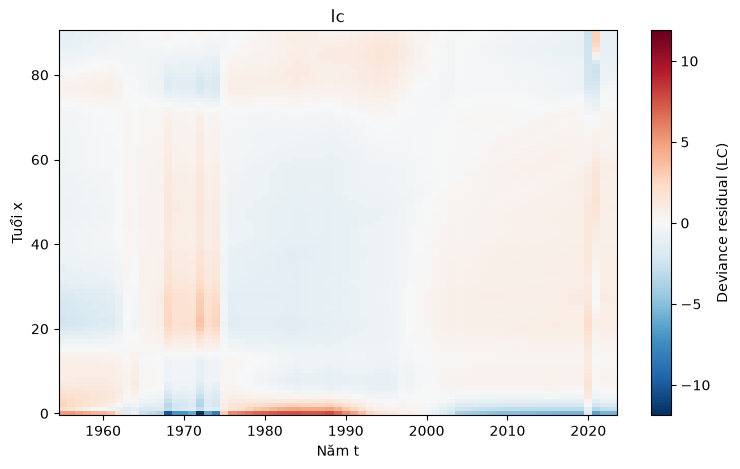

In [5]:
from src.visualization.plots import plot_residual_heatmap

plot_residual_heatmap(residuals_lc, model="lc", ylabel="Deviance residual (LC)")

In [6]:
from src.evaluation.cohort import cohort_mean_residual

cohort_resid_lc = cohort_mean_residual(residuals_lc, min_obs=40)
print("Khoảng biến thiên residual trung bình theo cohort (n>=40):",
      round(cohort_resid_lc.min(), 3), "->", round(cohort_resid_lc.max(), 3))
cohort_resid_lc.sort_values(ascending=False).head(5).round(3).to_frame("mean_residual")

Khoảng biến thiên residual trung bình theo cohort (n>=40): -0.411 -> 0.67


,mean_residual
1984,0.670
1983,0.648
1982,0.624
1981,0.587
1980,0.545


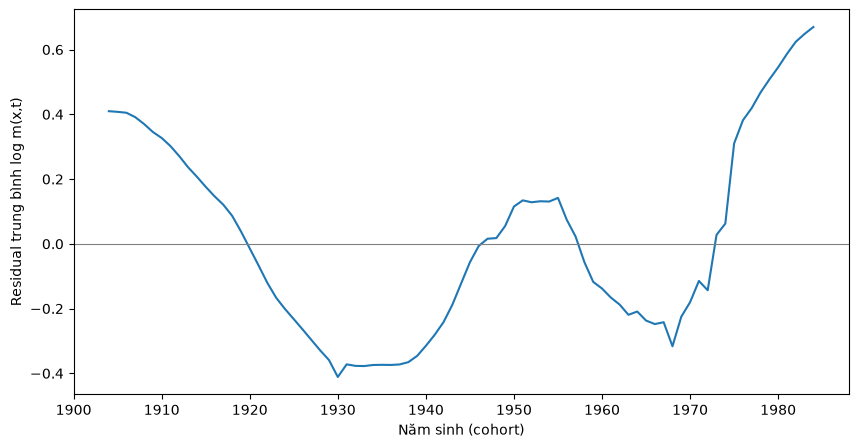

In [7]:
from src.visualization.plots import plot_cohort_mean_residual

plot_cohort_mean_residual(cohort_resid_lc, name="lc_cohort_mean_residual")

**Nhận xét:**

- Deviance residual trung bình theo cohort (n≥40 ô tuổi-năm) dao động khá rộng,
  từ **−0.41 (cohort 1930-1936)** đến **+0.67 (cohort 1980-1984)** — không phải
  nhiễu quanh 0 mà là một mô thức có hệ thống theo cohort, đúng như dự đoán:
  LC không có cấu phần cohort ($\gamma_c$) nên bất kỳ hiệu ứng thế hệ thật nào
  trong dữ liệu đều bị dồn hết vào residual.
- **Lưu ý**: mô thức cohort ở đây (đỉnh dương ở cohort 1980-1984, tuổi trẻ nhất
  trong mẫu) khác với "gò" quan sát được ở notebook 02 (đỉnh dương ở cohort
  1950-1954) — hai phép tính không tương đương: notebook 02 dùng phân rã naive
  trực tiếp trên log mx (giả định ngầm $b_x=1$ mọi tuổi), còn ở đây là deviance
  residual thật của LC (đã dùng đúng $b_x$ ước lượng, thang Poisson thay vì
  thang log). Sự khác biệt này bản thân nó là bằng chứng cho thấy giả định
  $b_x=1$ ở notebook 02 có ảnh hưởng đáng kể — càng củng cố lý do cần
  Renshaw-Haberman (notebook 05) để ước lượng $\gamma_c$ một cách chính thức
  thay vì suy diễn từ residual naive hay residual của một mô hình không có cohort.